# 🔍 Détection de Fraude Bancaire — Projet ML Complet

**Technologies :** Python · pandas · scikit-learn · XGBoost · SMOTE · SHAP · Streamlit

**Dataset :** [Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud) — 284,807 transactions, 492 fraudes (0.17%)

---
### Plan du notebook
1. Installation et imports
2. Chargement et EDA
3. Preprocessing
4. SMOTE — Gestion du déséquilibre
5. Entraînement des modèles
6. Comparaison et évaluation
7. Explainabilité SHAP
8. Sauvegarde du modèle


## 1. Installation et imports

In [11]:
# Installer les dépendances si nécessaire
# !pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn shap streamlit joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, f1_score, RocCurveDisplay
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import shap
import joblib

print('✓ Imports réussis')

✓ Imports réussis


## 2. Chargement et exploration (EDA)

In [12]:
df = pd.read_csv('creditcard.csv')
print(f'Shape: {df.shape}')
print(f'Fraudes: {df["Class"].sum()} ({df["Class"].mean()*100:.3f}%)')
df.head()

Shape: (284807, 31)
Fraudes: 492 (0.173%)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


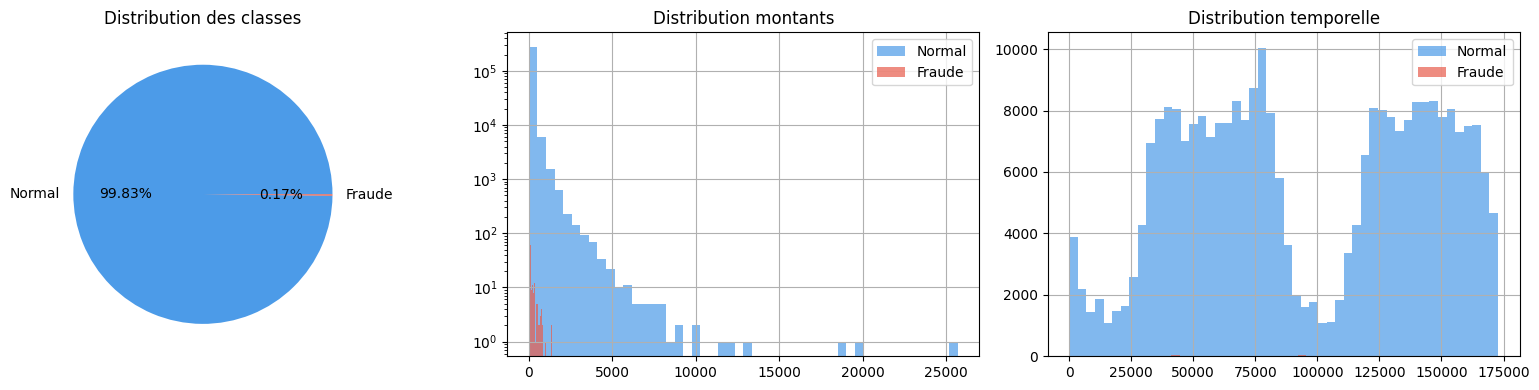

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].pie(df['Class'].value_counts(), labels=['Normal', 'Fraude'],
            autopct='%1.2f%%', colors=['#4C9BE8', '#E85C4C'])
axes[0].set_title('Distribution des classes')

df[df['Class']==0]['Amount'].hist(ax=axes[1], bins=50, alpha=0.7,
    color='#4C9BE8', label='Normal')
df[df['Class']==1]['Amount'].hist(ax=axes[1], bins=50, alpha=0.7,
    color='#E85C4C', label='Fraude')
axes[1].set_title('Distribution montants')
axes[1].set_yscale('log')
axes[1].legend()

df[df['Class']==0]['Time'].hist(ax=axes[2], bins=50, alpha=0.7,
    color='#4C9BE8', label='Normal')
df[df['Class']==1]['Time'].hist(ax=axes[2], bins=50, alpha=0.7,
    color='#E85C4C', label='Fraude')
axes[2].set_title('Distribution temporelle')
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Preprocessing

In [14]:
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])
df_clean = df.drop(columns=['Amount', 'Time'])

X = df_clean.drop(columns=['Class'])
y = df_clean['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Fraudes train: {y_train.sum()} | Fraudes test: {y_test.sum()}')

Train: 227845 | Test: 56962
Fraudes train: 394 | Fraudes test: 98


## 4. SMOTE — Rééquilibrage des classes

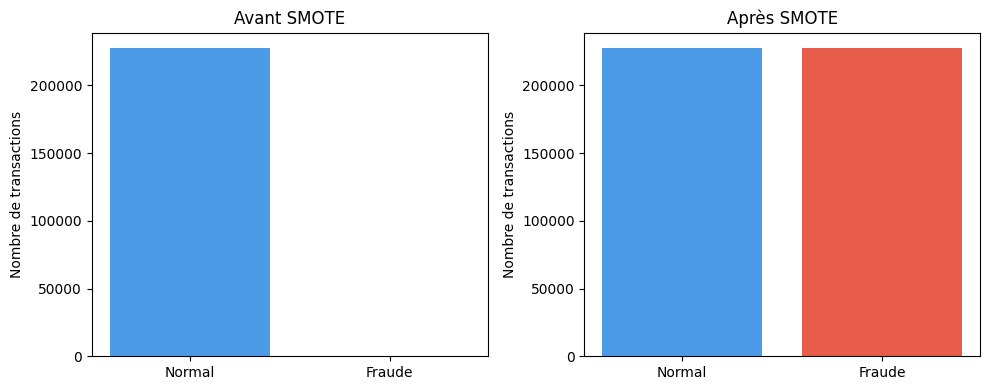

Après SMOTE — Normal: 227451, Fraude: 227451


In [15]:
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(
    axes,
    [y_train.value_counts(), pd.Series(y_train_res).value_counts()],
    ['Avant SMOTE', 'Après SMOTE']
):
    ax.bar(['Normal', 'Fraude'], counts.values, color=['#4C9BE8', '#E85C4C'])
    ax.set_title(title)
    ax.set_ylabel('Nombre de transactions')
plt.tight_layout()
plt.show()
print(f'Après SMOTE — Normal: {(y_train_res==0).sum()}, Fraude: {(y_train_res==1).sum()}')

## 5. Entraînement des modèles

In [16]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost':             XGBClassifier(
        n_estimators=100, learning_rate=0.1, max_depth=5,
        scale_pos_weight=len(y_train[y_train==0])/len(y_train[y_train==1]),
        random_state=42, eval_metric='logloss', verbosity=0
    )
}

results = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_res, y_train_res)
    else:
        model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    results[name] = {
        'model': model, 'y_pred': y_pred, 'y_proba': y_proba,
        'AUC-ROC':   round(roc_auc_score(y_test, y_proba), 4),
        'F1-Score':  round(f1_score(y_test, y_pred), 4),
    }
    print(f'{name:25s} | AUC={results[name]["AUC-ROC"]} | F1={results[name]["F1-Score"]}')

Logistic Regression       | AUC=0.9698 | F1=0.1094
Random Forest             | AUC=0.9528 | F1=0.8743
XGBoost                   | AUC=0.9755 | F1=0.6562


## 6. Comparaison et visualisation

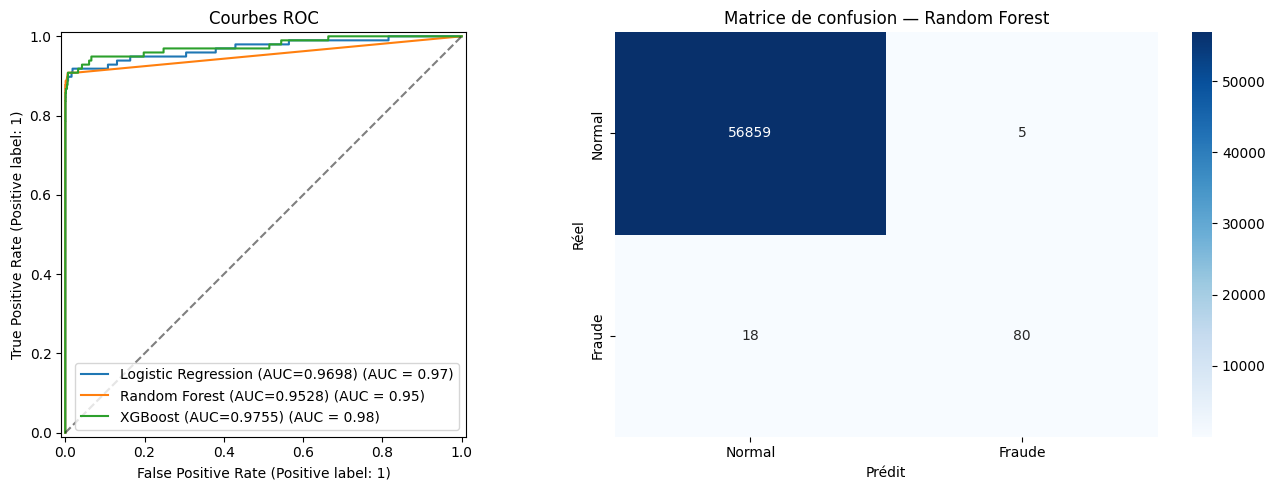

Meilleur modèle : Random Forest


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, res in results.items():
    RocCurveDisplay.from_predictions(
        y_test, res['y_proba'],
        name=f"{name} (AUC={res['AUC-ROC']})",
        ax=axes[0]
    )
axes[0].plot([0,1],[0,1],'k--', alpha=0.5)
axes[0].set_title('Courbes ROC')

best = max(results, key=lambda x: results[x]['F1-Score'])
cm = confusion_matrix(y_test, results[best]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Normal','Fraude'], yticklabels=['Normal','Fraude'], ax=axes[1])
axes[1].set_title(f'Matrice de confusion — {best}')
axes[1].set_ylabel('Réel') ; axes[1].set_xlabel('Prédit')

plt.tight_layout()
plt.show()
print(f'Meilleur modèle : {best}')

## 7. Explainabilité avec SHAP

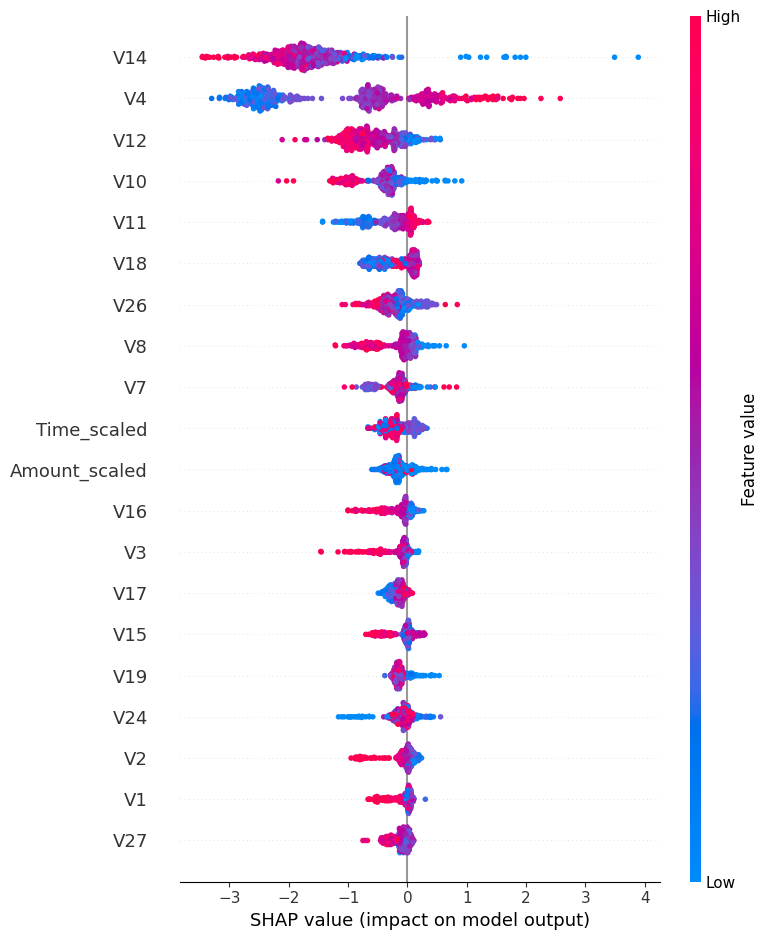

In [18]:
best_model = results['XGBoost']['model']
explainer  = shap.TreeExplainer(best_model)
X_sample   = X_test.sample(n=500, random_state=42)
shap_vals  = explainer.shap_values(X_sample)

# Summary plot
shap.summary_plot(shap_vals, X_sample, show=True)

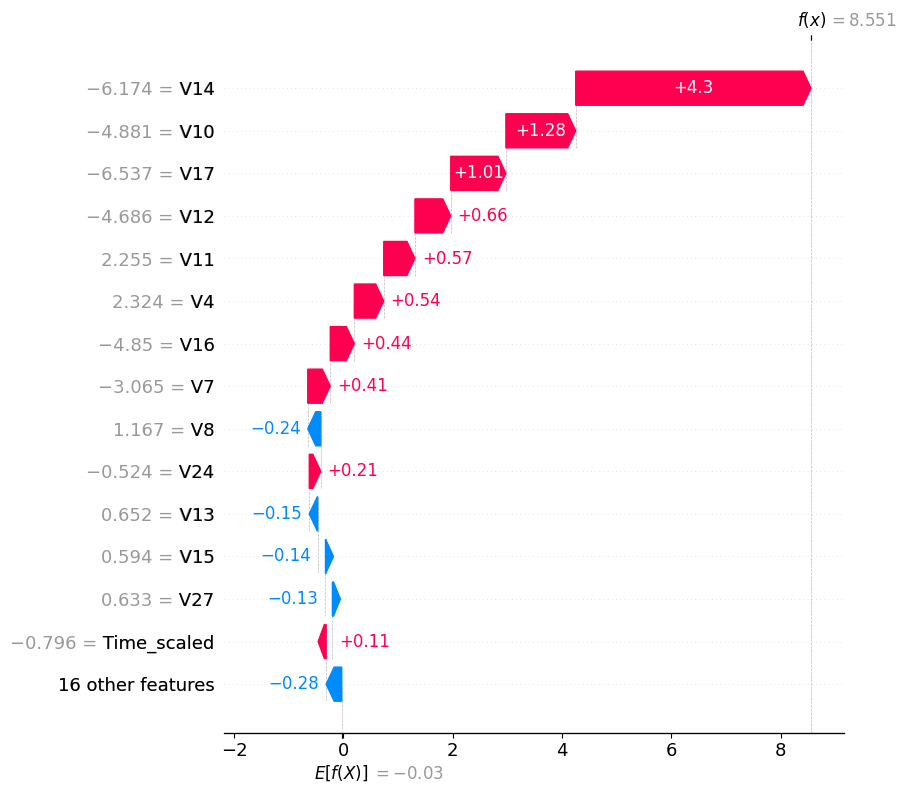

In [ ]:
# Waterfall plot — une transaction frauduleuse
fraud_idx = X_test[y_test==1].index[0]
shap_fraud = explainer(X_test.loc[[fraud_idx]])
shap.waterfall_plot(shap_fraud[0], max_display=15)

## 8. Sauvegarde du modèle

In [ ]:
joblib.dump(best_model, 'fraud_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(explainer,  'shap_explainer.pkl')
print('✓ Modèle, scaler et explainer sauvegardés')
print('Lancer le dashboard : streamlit run app.py')

✓ Modèle, scaler et explainer sauvegardés
Lancer le dashboard : streamlit run app.py
